In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt
import cv2
import random
import math
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models
from torchvision.models.resnet import resnet50
from sklearn.model_selection import train_test_split
import tensorflow as tf
from PIL import Image

ModuleNotFoundError: No module named 'cv2'

In [ ]:
! pip install kaggle
! mkdir ~/.kaggle

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets list

ref                                                                title                                              size  lastUpdated          downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  ------------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
arnabchaki/data-science-salaries-2023                              Data Science Salaries 2023 💸                       25KB  2023-04-13 09:55:16          13024        349  1.0              
asahu40/walmart-data-analysis-and-forcasting                       Walmart Data Analysis and Forcasting              122KB  2023-04-26 07:07:03           2005         46  1.0              
ahmedshahriarsakib/usa-real-estate-dataset                         USA Real Estate Dataset                             1MB  2023-04-30 03:51:36           1672         45  1.0              
iammustafatz/diabetes-prediction-dataset               

In [ ]:
! kaggle datasets download -d nih-chest-xrays/data

100% 42.0G/42.0G [05:03<00:00, 172MB/s]
100% 42.0G/42.0G [05:03<00:00, 148MB/s]


In [ ]:
!unzip "data.zip"

Streaming output truncated to the last 5000 lines.
  inflating: images_012/images/00028897_016.png  
  inflating: images_012/images/00028897_017.png  
  inflating: images_012/images/00028897_018.png  
  inflating: images_012/images/00028897_019.png  
  inflating: images_012/images/00028897_020.png  
  inflating: images_012/images/00028898_000.png  
  inflating: images_012/images/00028899_000.png  
  inflating: images_012/images/00028899_001.png  
  inflating: images_012/images/00028899_002.png  
  inflating: images_012/images/00028900_000.png  
  inflating: images_012/images/00028901_000.png  
  inflating: images_012/images/00028901_001.png  
  inflating: images_012/images/00028902_000.png  
  inflating: images_012/images/00028902_001.png  
  inflating: images_012/images/00028902_002.png  
  inflating: images_012/images/00028902_003.png  
  inflating: images_012/images/00028902_004.png  
  inflating: images_012/images/00028902_005.png  
  inflating: images_012/images/00028902_006.png  

In [ ]:
xray_data = pd.read_csv('Data_Entry_2017.csv')
xray_data.head(5)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


## Get number of observation and Plot some gray scale images

In [ ]:
total_number_of_observations = len(xray_data)
print('Number of observations:',total_number_of_observations)

Number of observations: 112120


In [ ]:
from glob import glob

my_glob = glob('images*/images/*.png')
print('Number of Observations: ', len(my_glob)) 

Number of Observations:  112120


In [ ]:
full_img_paths = {os.path.basename(x): x for x in my_glob}

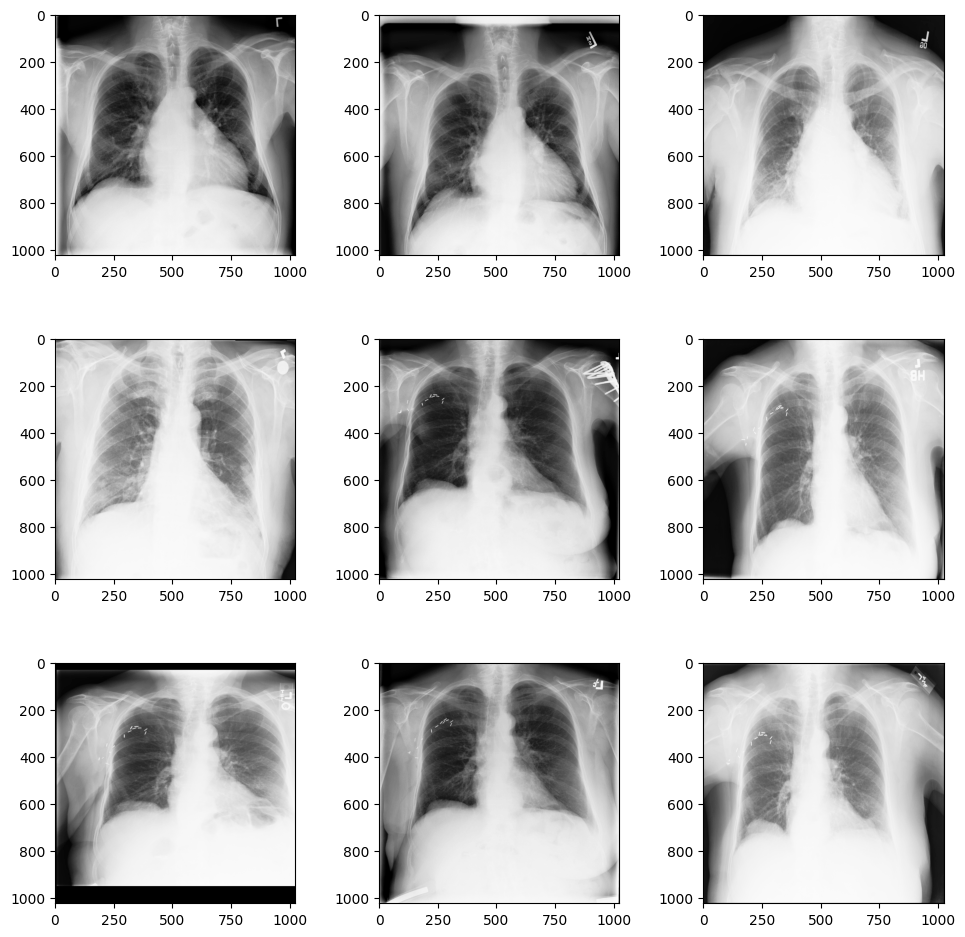

In [ ]:
fig = plt.figure(figsize=(10, 10))
i = 1
for ii in xray_data['Image Index'].values[:9]:
    img = plt.imread(full_img_paths[ii])
    fig.add_subplot(3,3,i)
    plt.imshow(img , cmap='Greys_r')
    i+=1
    
fig.tight_layout(pad=2)
fig.show()

In [ ]:
all_xray_df = pd.read_csv('Data_Entry_2017.csv')
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join('images*', '*', '*.png'))}
print('Scans found:', len(all_image_paths), ', Total Headers', all_xray_df.shape[0])
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].map(lambda x: int(x))
all_xray_df['Binary Labels'] = all_xray_df['Finding Labels'].map(lambda x: 0.0 if x == 'No Finding' else 1.0)
all_xray_df.sample(3)

Scans found: 112120 , Total Headers 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,path,Binary Labels
12247,00003190_017.png,No Finding,17,3190,40,F,AP,2048,2500,0.168,0.168,NaN,images_002/images/00003190_017.png,0.0
74816,00018362_012.png,Effusion,12,18362,47,M,PA,3004,2500,0.139,0.139,NaN,images_008/images/00018362_012.png,1.0
24632,00006479_003.png,No Finding,3,6479,49,F,PA,2048,2500,0.171,0.171,NaN,images_003/images/00006479_003.png,0.0


#Sampling Data and Dataset Splitting

In [ ]:
print('Before sampling...')
label_counts = all_xray_df['Binary Labels'].value_counts()
print(label_counts)

print('After sampling...')
all_xray_df = all_xray_df.sample(11000, random_state=7)
label_counts = all_xray_df['Binary Labels'].value_counts()
print(label_counts)
all_xray_df.sample(3)

print("\n")

images = list(all_xray_df['path'])
labels = list(all_xray_df['Binary Labels'].map(lambda x: [x]))
from sklearn.model_selection import train_test_split
train_img, val_img, train_label, val_label = train_test_split(images, labels, 
                                   test_size = 1000, 
                                   random_state = 7,
                                   stratify = labels)
print('train:', len(train_img), '\nvalidation:', len(val_img))

Before sampling...
0.0    60361
1.0    51759
Name: Binary Labels, dtype: int64
After sampling...
0.0    5841
1.0    5159
Name: Binary Labels, dtype: int64


train: 10000 
validation: 1000


In [ ]:
full_img_paths = {os.path.basename(x): x for x in my_glob}

Custom Class inherited from Nerual Network Module 

In [ ]:
class Net(nn.Module):
    def __init__(self, model):
        super(Net, self).__init__()
        self.resnet_layer = nn.Sequential(*list(model.children())[:-1])
        self.Linear_layer = nn.Linear(2048, 1)
        self.out = nn.Sigmoid()

    def forward(self, x):
        x = self.resnet_layer(x)
        x = x.view(x.size(0), -1)
        x = self.Linear_layer(x)
        x = self.out(x)
        return x

my_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
])

from torchsummary import summary
resnet_now = resnet50(pretrained=True)
model = Net(resnet_now)
summary(model, input_size=(3, 224, 224), device='cpu')

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 95.8MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [ ]:
class CustomSet(Dataset):
    def __init__(self,Data,Label,transform=None):
        self.images = Data
        self.label = Label
        self.transform = transform
        
    def __getitem__(self, index):
        label = self.label[index]
        temp = np.array(cv2.imread(self.images[index]))
        try:
          temp = (temp * 255).round().astype(np.uint8)
        except:
          print(self.images[index])
        img = Image.fromarray(temp)
        if self.transform:
          img = self.transform(img)
        label = torch.Tensor([label])
        label = label.to(torch.float)
        return img, label
        
    def __len__(self):
        return len(self.images)

In [ ]:
train = CustomSet(train_img, train_label, transform = my_transform)
trainloader = DataLoader(train, batch_size=32, shuffle=True, num_workers = 2)

val = CustomSet(val_img, val_label, transform = my_transform)
validloader = DataLoader(val, batch_size=32, shuffle=False, num_workers = 2)

device = torch.device("cuda")
model = model.to(device)

#track validation loss changes
valid_loss_min = np.Inf # track change in validation loss
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.0002, momentum = 0.9 ,weight_decay=0.00002 )
n_epochs = 15

train_ac = []
test_ac = []
t_loss = []
v_loss = []


#ResNet model training 

In [ ]:
from tqdm import tqdm

trainingLoss = []
trainingAcc = []

validationLoss = []
validationAcc = []

for epoch in tqdm(range(1, n_epochs+1)):
    torch.cuda.empty_cache()
    train_loss = 0.0
    valid_loss = 0.0
    print('running epoch: {}'.format(epoch))
    model.train()
    train_correct = 0
    train_total = 0
    for data, target in trainloader:
        target = target.squeeze(1)
        # move tensors to GPU if CUDA is available
        data, target = data.to(device), target.to(device)
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update training loss
        train_loss += loss.item()*data.size(0)
        # update training Accuracy
        train_total += target.size(0)
        predicted = (output>0.5).float()
        train_correct += (predicted == target).sum().item()


    # validate the model
    model.eval()
    valid_correct = 0
    valid_total = 0
    for data, target in validloader:
        target = target.squeeze(1)
        data, target = data.to(device), target.to(device)
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        loss = criterion(output, target)
        # update average validation loss 
        valid_loss += loss.item()*data.size(0)
        # update validation Accuracy
        valid_total += target.size(0)
        #_, predicted = torch.max(output.data, 1)
        predicted = (output>0.5).float()
        valid_correct += (predicted == target).sum().item()


    #Statistics
    train_loss = train_loss/len(trainloader.dataset)
    valid_loss = valid_loss/len(validloader.dataset)
    t_loss.append(train_loss)
    v_loss.append(valid_loss)
    train_ac.append(100 * train_correct / train_total)
    test_ac.append(100 * valid_correct / valid_total) 

    print('Train Loss: {}'.format(train_loss))
    print('Validation Loss: {}'.format(valid_loss))
    print('Train Accuracy: {}'.format(100 * train_correct / train_total))
    print('Validation Accuracy: {}'.format(100 * valid_correct / valid_total))

    trainingLoss.append(train_loss)
    trainingAcc.append(100 * train_correct / train_total)

    validationLoss.append(valid_loss)
    validationAcc.append(100 * valid_correct / valid_total)


  0%|          | 0/15 [00:00<?, ?it/s]

running epoch: 1



  7%|▋         | 1/15 [02:19<32:37, 139.81s/it]

Train Loss: 0.38431928033828733
Validation Loss: 0.8112459640502929
Train Accuracy: 83.31
Validation Accuracy: 60.7
running epoch: 2



 13%|█▎        | 2/15 [04:38<30:06, 138.94s/it]

...

Train Loss: 0.13532861673235894
Validation Loss: 1.1312202124595643
Train Accuracy: 95.13
Validation Accuracy: 66.9
running epoch: 14



 93%|█████████▎| 14/15 [32:59<02:20, 140.92s/it]

Train Loss: 0.12976966112852095
Validation Loss: 1.132037561893463
Train Accuracy: 95.35
Validation Accuracy: 64.7
running epoch: 15


100%|██████████| 15/15 [35:18<00:00, 141.27s/it]

Train Loss: 0.12374356639385223
Validation Loss: 1.1926278557777406
Train Accuracy: 95.4
Validation Accuracy: 64.1


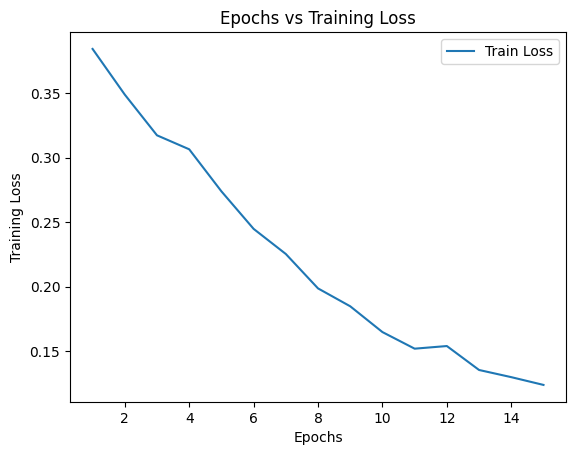

In [ ]:
epochs = list(range(1,16))

plt.plot(epochs, trainingLoss, label = "Train Loss")
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Epochs vs Training Loss')
plt.legend()
plt.show()

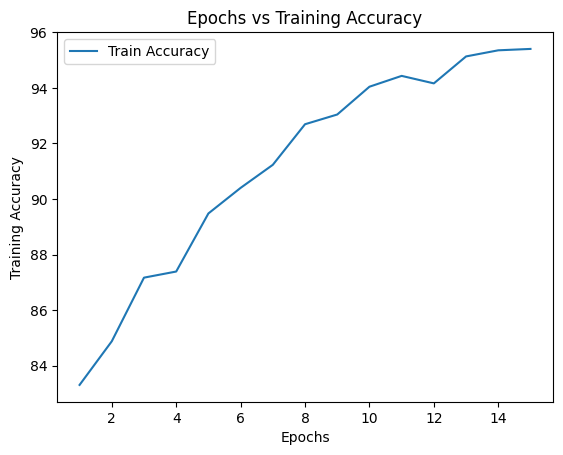

In [ ]:
plt.plot(epochs, trainingAcc, label = "Train Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.title('Epochs vs Training Accuracy')
plt.legend()
plt.show()

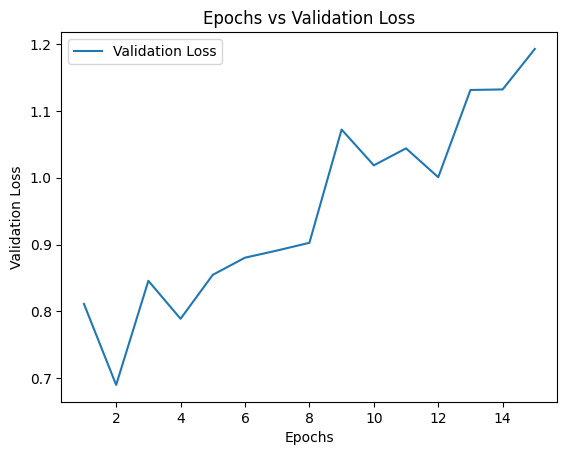

In [ ]:
plt.plot(epochs, validationLoss, label = "Validation Loss")
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Epochs vs Validation Loss')
plt.legend()
plt.show()

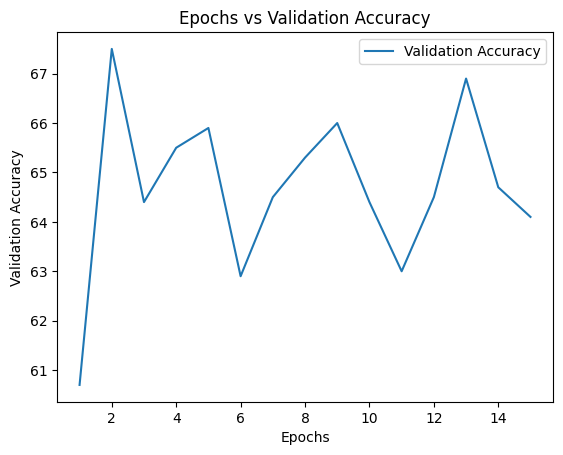

In [ ]:
plt.plot(epochs, validationAcc, label = "Validation Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Epochs vs Validation Accuracy')
plt.legend()
plt.show()

# Mobilenet Model

MobileNet is a type of deep convolutional neural network architecture that is computationally efficient, using depthwise separable convolutions to reduce the number of computations required for each convolutional layer.

MobileNet has a relatively small number of parameters compared to other popular neural network architectures, such as VGGNet and ResNet, which makes it well-suited for mobile and embedded devices with limited computational resources. However, despite its smaller size, MobileNet is still capable of achieving high accuracy on a variety of computer vision tasks, including image classification and object detection.

In the context of lung disease prediction, MobileNet can be used as a base model for transfer learning, where the pre-trained weights of the model are used as a starting point for training a new set of classification layers on top. The pre-trained MobileNet model can be fine-tuned on a dataset of chest X-ray images, and the resulting model can be used to predict the presence or absence of lung disease in new images.

In [ ]:
import pandas as pd
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

## Load Data

In [ ]:
all_xray_df = pd.read_csv('Data_Entry_2017.csv')
all_image_paths = {os.path.basename(x): x for x in glob(os.path.join('images*', '*', '*.png'))}
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].map(lambda x: int(x))

## Define data generator & Create train and validation data generators

When training deep learning models on image data, it's necessary to use a generator to feed the data into the model in batches, as loading all the images into memory at once may not be feasible or efficient. A generator allows us to load and preprocess the images on-the-fly, as they are needed by the model during training.

In [ ]:
# Define data generator
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Create train and validation data generators
train_generator = datagen.flow_from_dataframe(
    dataframe=all_xray_df,
    directory=None,
    x_col='path',
    y_col='Finding Labels',
    subset='training',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

val_generator = datagen.flow_from_dataframe(
    dataframe=all_xray_df,
    directory=None,
    x_col='path',
    y_col='Finding Labels',
    subset='validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

Found 89696 validated image filenames belonging to 836 classes.
Found 22424 validated image filenames belonging to 836 classes.


## Load pre-trained MobileNet model without top layers

Loads the pre-trained MobileNet model from the Keras library, using the 'imagenet' weights. The include_top parameter is set to False to exclude the top layers (i.e. the classification layers), and input_shape is set to (224, 224, 3) to specify the expected input shape for the model.

In [ ]:
base_model = MobileNet(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

17225924/17225924 [==============================] - 0s 0us/step


## Add new top layers for classification

When we load a pre-trained model without its top layers, the resulting model consists of the convolutional layers that can extract useful features from the input image. However, we still need to add some new layers to the top of the model for the specific classification task we want to perform.

To do this, we typically add one or more dense (fully connected) layers, followed by a final output layer with the appropriate number of units for our classification problem. We can freeze the convolutional layers so that their weights are not updated during training, and only train the new top layers. This is called transfer learning, where we use the pre-trained weights as a starting point for our own model, and fine-tune it for our specific task.

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(len(train_generator.class_indices), activation='softmax')(x)

## Create model with new top layers

In [ ]:
base_model = MobileNet(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Add new top layers for classification
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(len(train_generator.class_indices), activation='softmax')(x)

# Create model with new top layers
model = Model(inputs=base_model.input, outputs=predictions)

## Freeze base model layers

When using a pre-trained model for transfer learning, it's common practice to freeze the weights of the base layers of the model during training of the new top layers. The base layers of the model are the layers that have already been trained on a large dataset (such as ImageNet) and have learned to extract general image features. By freezing these layers, we prevent them from being updated during training of the new top layers, which allows us to retain the previously learned features.

In [ ]:
# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

## Compile model

In [ ]:
model.compile(optimizer=Adam(lr=0.001), loss='categorical_crossentropy', metrics=['accuracy'])


## Train model

In [ ]:
device = torch.device("cuda")


# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1)

Epoch 1/10
2803/2803 [==============================] - 1818s 645ms/step - loss: 2.4124 - accuracy: 0.5270 - val_loss: 2.1808 - val_accuracy: 0.5819
Epoch 2/10
2803/2803 [==============================] - 1808s 645ms/step - loss: 2.3006 - accuracy: 0.5277 - val_loss: 2.1741 - val_accuracy: 0.5802
Epoch 3/10
2803/2803 [==============================] - 1824s 651ms/step - loss: 2.2644 - accuracy: 0.5281 - val_loss: 2.1653 - val_accuracy: 0.5810
Epoch 4/10
2803/2803 [==============================] - 1856s 662ms/step - loss: 2.2350 - accuracy: 0.5283 - val_loss: 2.1765 - val_accuracy: 0.5797
Epoch 5/10
2803/2803 [==============================] - 1848s 659ms/step - loss: 2.2163 - accuracy: 0.5278 - val_loss: 2.1763 - val_accuracy: 0.5816
Epoch 6/10
2803/2803 [==============================] - 1822s 650ms/step - loss: 2.2022 - accuracy: 0.5292 - val_loss: 2.1978 - val_accuracy: 0.5814
Epoch 7/10
2803/2803 [==============================] - 1811s 646ms/step - loss: 2.1893 - accuracy: 0.5285

## Plot accuracy and loss

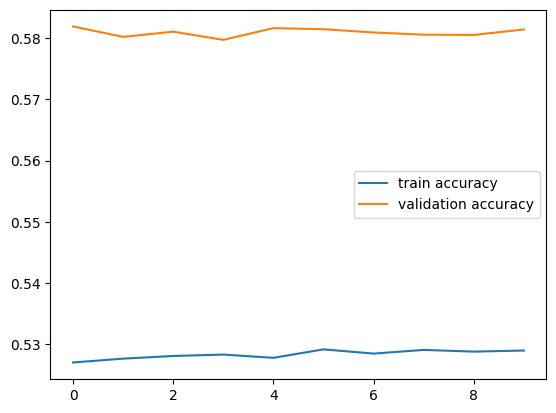

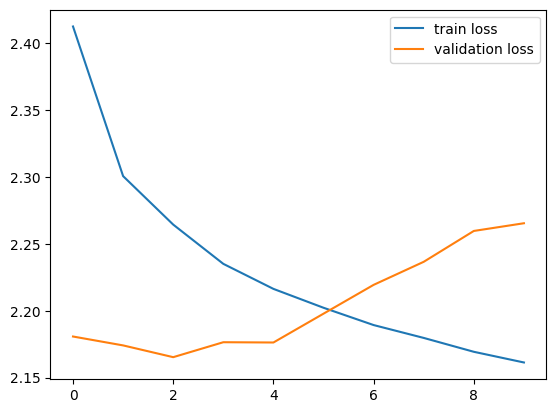

In [ ]:
# Plot accuracy and loss
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()


plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

## VGGnet Model

VGGnet is a deep convolutional neural network architecture that was proposed by the Visual Geometry Group at Oxford University in 2014. It was one of the first deep CNNs to achieve state-of-the-art performance on the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) in 2014, and has since become a popular base architecture for many computer vision tasks.

The VGGnet architecture consists of a series of convolutional layers followed by max pooling layers, with a final series of fully connected (dense) layers for classification. The key feature of the VGGnet architecture is the use of very small (3x3) convolutional filters, which allows the network to learn richer feature representations by stacking more layers. The architecture is typically specified by the number of layers (VGG16 has 16 layers, VGG19 has 19 layers), which can be customized for different tasks.

For lung disease prediction, we can use the VGGnet architecture as a base model for transfer learning. We can load a pre-trained VGGnet model (such as VGG16 or VGG19) without the top layers (i.e., the final fully connected layers), and add our own top layers for classification. The base VGGnet layers can be frozen during training of the new top layers, to retain the learned feature representations.

In [ ]:
import pandas as pd
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

## Load data

In [ ]:
all_xray_df = pd.read_csv('Data_Entry_2017.csv')
all_image_paths = {os.path.basename(x): x for x in glob(os.path.join('images*', '*', '*.png'))}
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].map(lambda x: int(x))

## Define data generator

In [ ]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Create train and validation data generators
train_generator = datagen.flow_from_dataframe(
    dataframe=all_xray_df,
    directory=None,
    x_col='path',
    y_col='Finding Labels',
    subset='training',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

val_generator = datagen.flow_from_dataframe(
    dataframe=all_xray_df,
    directory=None,
    x_col='path',
    y_col='Finding Labels',
    subset='validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

Found 89696 validated image filenames belonging to 836 classes.
Found 22424 validated image filenames belonging to 836 classes.


## Load pre-trained VGG16 model without top layers

In [ ]:
base_model = VGG16(input_shape=(224, 224, 3), include_top=False, weights='imagenet')


58889256/58889256 [==============================] - 0s 0us/step


## Add new top layers for classification


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(len(train_generator.class_indices), activation='softmax')(x)


## Create model with new top layers

In [ ]:
model = Model(inputs=base_model.input, outputs=predictions)


## Freeze base model layers

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

## Compile model

In [ ]:
model.compile(optimizer=Adam(lr=0.001), loss='categorical_crossentropy', metrics=['accuracy'])


## Train model

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1)

Epoch 1/10
2803/2803 [==============================] - 1937s 686ms/step - loss: 2.4720 - accuracy: 0.5273 - val_loss: 2.2280 - val_accuracy: 0.5811
Epoch 2/10
2803/2803 [==============================] - 2026s 723ms/step - loss: 2.3819 - accuracy: 0.5275 - val_loss: 2.1981 - val_accuracy: 0.5818
Epoch 3/10
2803/2803 [==============================] - 1983s 708ms/step - loss: 2.3520 - accuracy: 0.5273 - val_loss: 2.1781 - val_accuracy: 0.5818
Epoch 4/10
2803/2803 [==============================] - 1978s 706ms/step - loss: 2.3299 - accuracy: 0.5277 - val_loss: 2.1836 - val_accuracy: 0.5811
Epoch 5/10
2803/2803 [==============================] - 1980s 706ms/step - loss: 2.3123 - accuracy: 0.5276 - val_loss: 2.1980 - val_accuracy: 0.5818
Epoch 6/10
2803/2803 [==============================] - 1956s 698ms/step - loss: 2.2963 - accuracy: 0.5278 - val_loss: 2.1885 - val_accuracy: 0.5805
Epoch 7/10
2803/2803 [==============================] - 1968s 702ms/step - loss: 2.2835 - accuracy: 0.5276

In [ ]:
# Print accuracy during training for each epoch
for i, acc in enumerate(history.history['accuracy']):
    print(f"Epoch {i+1} - accuracy: {acc:.4f}")

Epoch 1 - accuracy: 0.5273
Epoch 2 - accuracy: 0.5275
Epoch 3 - accuracy: 0.5273
Epoch 4 - accuracy: 0.5277
Epoch 5 - accuracy: 0.5276
Epoch 6 - accuracy: 0.5278
Epoch 7 - accuracy: 0.5276
Epoch 8 - accuracy: 0.5280
Epoch 9 - accuracy: 0.5279
Epoch 10 - accuracy: 0.5282


## Plot accuracy and loss

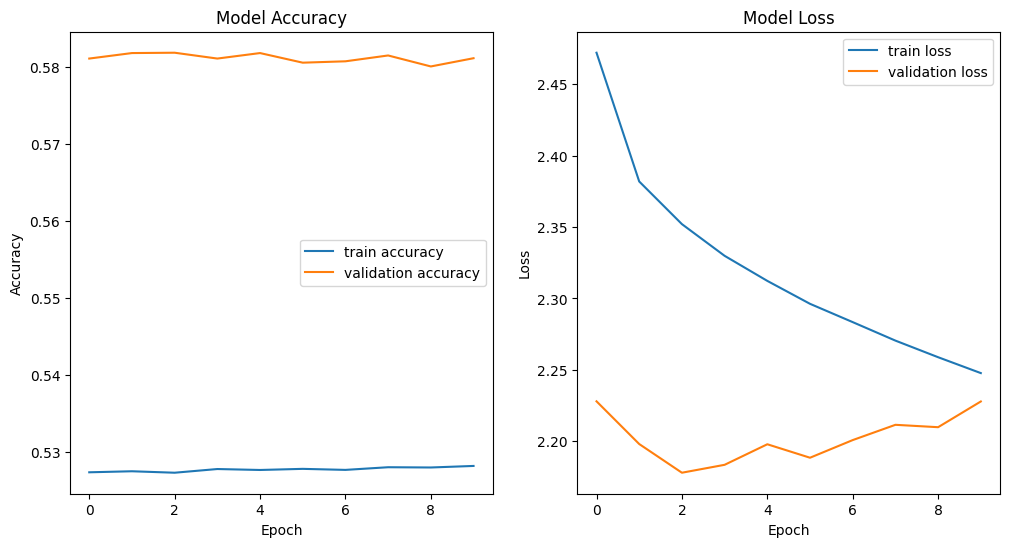

In [ ]:

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()